In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# What factors influence traffic crashes in NYC?

In [144]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/utku-explo/clean_crash_data.csv")

In [145]:
main_df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'COLLISION_ID', 'day_of_week',
       'is_weekend', 'hour', 'injury_flag', 'vehicle_category'],
      dtype='object')

In [146]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car


In [147]:
main_df['ZIP CODE'].value_counts()

ZIP CODE
0        482091
11207     30712
11236     21210
11101     20703
11203     20122
          ...  
11371         1
10162         1
11241         1
10166         1
12345         1
Name: count, Length: 236, dtype: int64

In [148]:
main_df['NUMBER OF PERSONS INJURED'].value_counts()

NUMBER OF PERSONS INJURED
0.0     1533831
1.0      392529
2.0       72094
3.0       23580
4.0        8571
5.0        3280
6.0        1324
7.0         555
8.0         249
9.0         120
10.0         90
11.0         49
12.0         32
13.0         27
15.0         16
14.0          8
17.0          8
16.0          7
18.0          6
20.0          4
22.0          3
19.0          3
24.0          3
21.0          1
34.0          1
25.0          1
23.0          1
31.0          1
27.0          1
32.0          1
43.0          1
Name: count, dtype: int64

<Axes: xlabel='NUMBER OF PERSONS INJURED', ylabel='hour'>

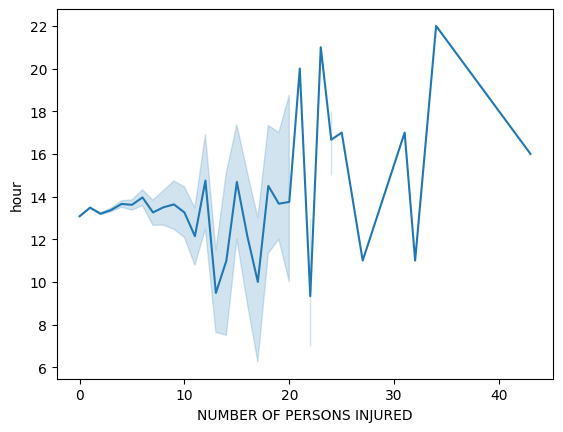

In [149]:
sns.lineplot(data=main_df,x='NUMBER OF PERSONS INJURED',y="hour")

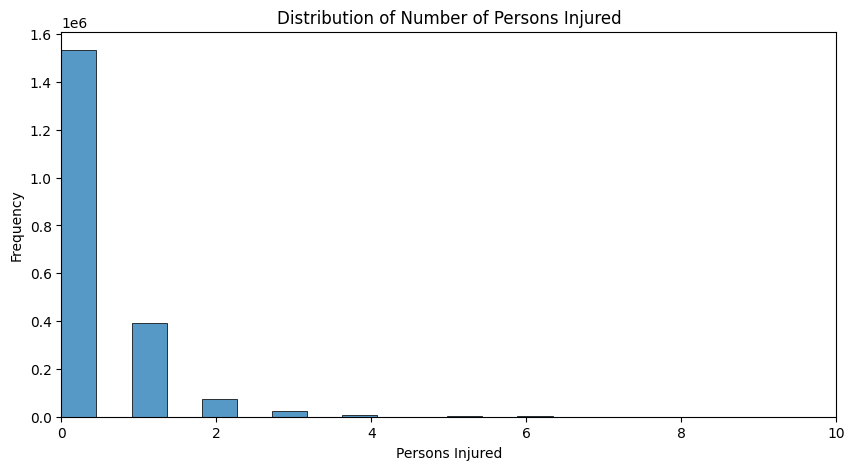

In [150]:
plt.figure(figsize=(10,5))
sns.histplot(main_df['NUMBER OF PERSONS INJURED'], bins=95)
plt.title('Distribution of Number of Persons Injured')
plt.xlabel('Persons Injured')
plt.ylabel('Frequency')
plt.xlim(0,10)
plt.show()

In [151]:
main_df.groupby('BOROUGH')['injury_flag']

In [152]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       680422
Driver Inattention/Distraction    421139
Failure to Yield Right-of-Way     125718
Following Too Closely             106670
Backing Unsafely                   76501
                                   ...  
Windshield Inadequate                 82
Cell Phone (hand-held)                66
Texting                               52
Listening/Using Headphones            24
1                                     10
Name: count, Length: 61, dtype: int64

In [153]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(10)

CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       680422
Driver Inattention/Distraction    421139
Failure to Yield Right-of-Way     125718
Following Too Closely             106670
Backing Unsafely                   76501
Other Vehicular                    64355
Passing or Lane Usage Improper     60119
Passing Too Closely                55097
Turning Improperly                 49290
Unsafe Lane Changing               39331
Name: count, dtype: int64

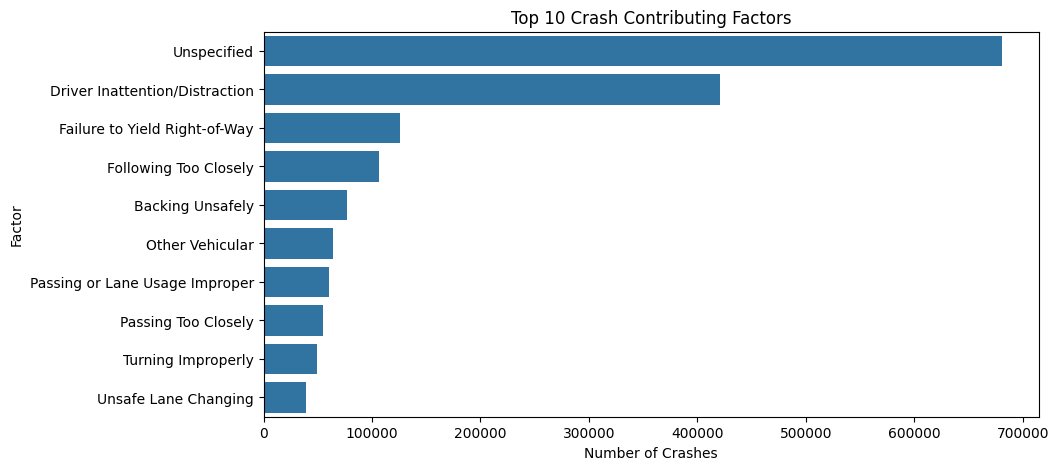

In [154]:
top10 = main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Crash Contributing Factors")
plt.xlabel("Number of Crashes")
plt.ylabel("Factor")

plt.show()

In [155]:
top10 = main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(10).index
top10=top10.drop("Unspecified")
def factor(x):
    if x in top10:
        return 1
    elif x=="Unspecified":
        return 0
    else:
        return 0
    



In [156]:
main_df['CONTRIBUTING FACTOR VEHICLE 1']=main_df['CONTRIBUTING FACTOR VEHICLE 1'].apply(factor)

In [157]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

CONTRIBUTING FACTOR VEHICLE 1
0    1038177
1     998220
Name: count, dtype: int64

In [158]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,0,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,0,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,0,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,1,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,0,4486660,1,0,8,1,Car


In [159]:
main_df['injury_flag'].value_counts()

injury_flag
0    1533831
1     502566
Name: count, dtype: int64

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_18768/2335139746.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=main_df ,x='injury_flag',palette='viridis')


Text(0, 0.5, 'Number of Crashes')

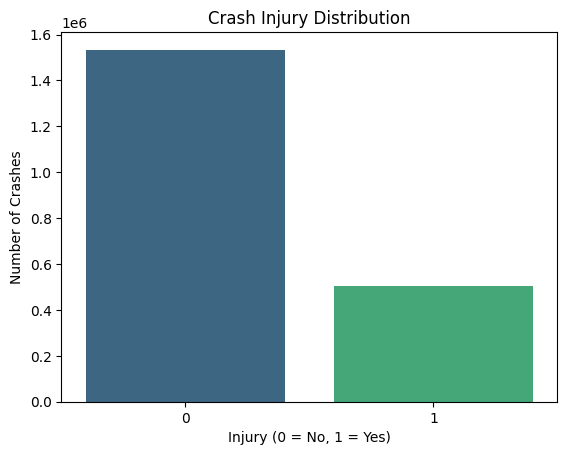

In [160]:
sns.countplot(data=main_df ,x='injury_flag',palette='viridis')
plt.title("Crash Injury Distribution")
plt.xlabel("Injury (0 = No, 1 = Yes)")
plt.ylabel("Number of Crashes")

In [162]:
main_df.groupby("hour")['injury_flag'].mean()

hour
0     0.270592
1     0.262638
2     0.265780
3     0.271393
4     0.279683
5     0.267865
6     0.261690
7     0.257463
8     0.222823
9     0.203669
10    0.197092
11    0.207777
12    0.214839
13    0.221622
14    0.226815
15    0.251538
16    0.235873
17    0.251759
18    0.268055
19    0.280501
20    0.292356
21    0.297863
22    0.291030
23    0.292147
Name: injury_flag, dtype: float64

In [163]:
main_df['COLLISION_ID']

0          4675373
1          4456314
2          4486609
3          4486555
4          4486660
            ...   
2036392    4882931
2036393    4882837
2036394    4883299
2036395    4883343
2036396    4882875
Name: COLLISION_ID, Length: 2036397, dtype: int64

In [164]:
main_df['COLLISION_ID'].duplicated().sum()

np.int64(0)

In [165]:
main_df['COLLISION_ID'].nunique()

2036397

In [171]:
main_df.groupby('BOROUGH')[['COLLISION_ID']].count()

,COLLISION_ID
BOROUGH,
BRONX,230307
BROOKLYN,498993
MANHATTAN,343626
QUEENS,416524
STATEN ISLAND,65150
UNKNOWN,481797


In [173]:
main_df.groupby('BOROUGH')[['injury_flag']].mean()

,injury_flag
BOROUGH,
BRONX,0.256010
BROOKLYN,0.264677
MANHATTAN,0.192226
QUEENS,0.240723
STATEN ISLAND,0.220721
UNKNOWN,0.271550


<Axes: ylabel='Count'>

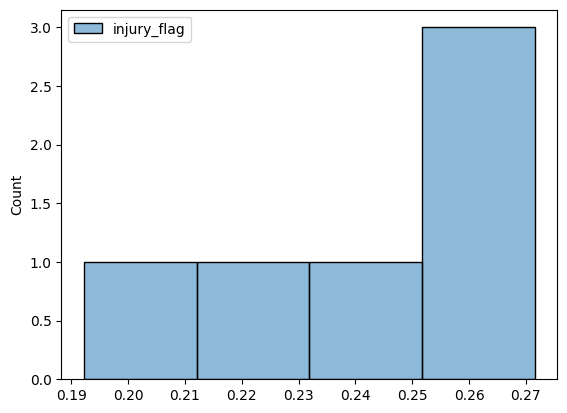

In [174]:
sns.histplot(main_df.groupby('BOROUGH')[['injury_flag']].mean())

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_18768/2421980381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=main_df, x="BOROUGH", y="injury_flag", palette="viridis")


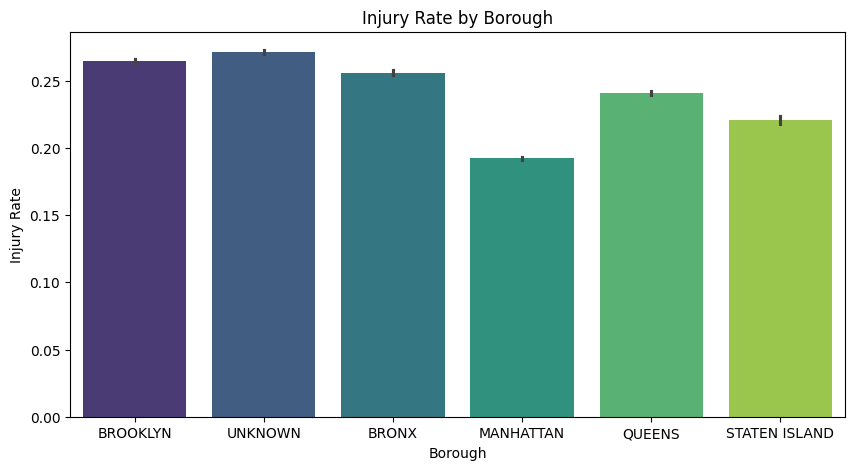

In [180]:
plt.figure(figsize=(10,5))
sns.barplot(data=main_df, x="BOROUGH", y="injury_flag", palette="viridis")
plt.title("Injury Rate by Borough")
plt.ylabel("Injury Rate")
plt.xlabel("Borough")
plt.show()

<Axes: xlabel='hour', ylabel='count'>

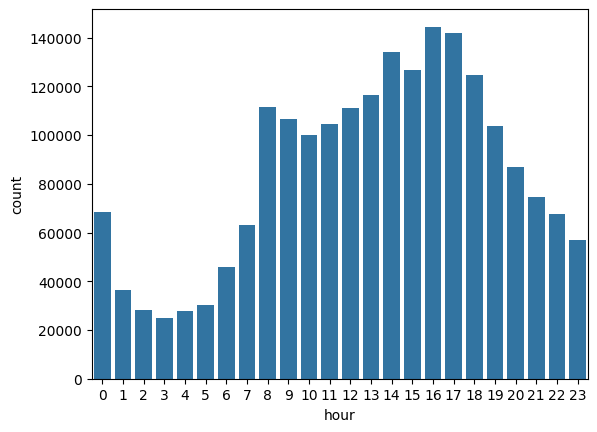

In [181]:
sns.countplot(data=main_df, x="hour")

In [184]:
main_df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'COLLISION_ID', 'day_of_week',
       'is_weekend', 'hour', 'injury_flag', 'vehicle_category'],
      dtype='object')

In [187]:
main_df['vehicle_category'].value_counts()

vehicle_category
Car      1084699
SUV       631666
Other     199984
Truck     120048
Name: count, dtype: int64

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_18768/2243815720.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(main_df['vehicle_category'].value_counts(),palette="viridis")


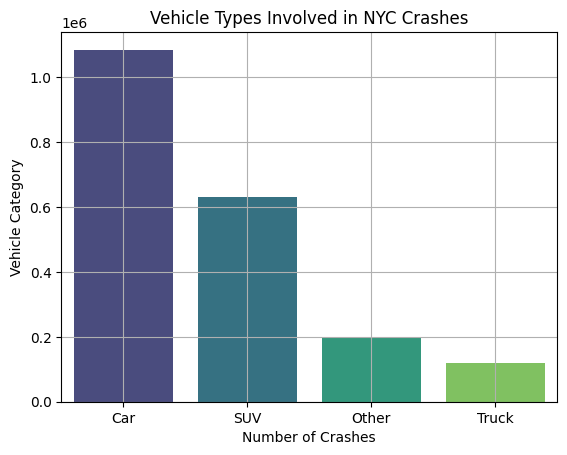

In [191]:
sns.barplot(main_df['vehicle_category'].value_counts(),palette="viridis")
plt.title("Vehicle Types Involved in NYC Crashes")
plt.xlabel("Number of Crashes")
plt.ylabel("Vehicle Category")
plt.grid()
